<a href="https://colab.research.google.com/github/stardust-96/Learning-Concepts/blob/main/Swin_ViT_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEMO: Tiny Swin (CIFAR-10, 32x32)

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def get_device():
    return "cuda" if torch.cuda.is_available() else "cpu"

# Window util

In [36]:
def window_partition(x, window_size: int):
    """
    x: (B, H, W, C)
    return windows: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    assert H % window_size == 0 and W % window_size == 0
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size: int, H: int, W: int, B: int):
    """
    windows: (num_windows*B, window_size, window_size, C)
    return x: (B, H, W, C)
    """
    C = windows.shape[-1]
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, C)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, C)
    return x


# Swin attention mask for shifted windows

In [37]:
def build_attn_mask(H, W, window_size, shift_size, device):
    """
    Returns:
      attn_mask: (nW, N, N) where N=window_size*window_size
      nW = number of windows per image
    Mask adds -inf between tokens from different regions after shift.
    """
    if shift_size == 0:
        return None

    img_mask = torch.zeros((1, H, W, 1), device=device)  # (1,H,W,1)
    cnt = 0

    h_slices = (
        slice(0, -window_size),
        slice(-window_size, -shift_size),
        slice(-shift_size, None),
    )
    w_slices = (
        slice(0, -window_size),
        slice(-window_size, -shift_size),
        slice(-shift_size, None),
    )

    for hs in h_slices:
        for ws in w_slices:
            img_mask[:, hs, ws, :] = cnt
            cnt += 1

    # partition mask into windows
    mask_windows = window_partition(img_mask, window_size)  # (nW, win, win, 1)
    mask_windows = mask_windows.view(-1, window_size * window_size)  # (nW, N)

    attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)  # (nW, N, N)
    # different -> -inf, same -> 0
    attn_mask = attn_mask.masked_fill(attn_mask != 0, float("-inf")).masked_fill(attn_mask == 0, 0.0)
    return attn_mask

In [38]:
# ----------------------------
# MLP
# ----------------------------
class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

# ----------------------------
# Window MSA with optional mask + returns attention when requested
# ----------------------------
class WindowMSA(nn.Module):
    def __init__(self, dim, num_heads, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, attn_mask=None, return_attn=False):
        """
        x: (B_, N, C)
        attn_mask: (nW, N, N) or None
        return_attn: if True, returns (out, attn)
          attn: (B_, heads, N, N) after softmax (and after mask)
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # (B_, heads, N, head_dim)

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))  # (B_, heads, N, N)

        if attn_mask is not None:
            # attn_mask: (nW, N, N)
            # B_ = B * nW
            nW = attn_mask.shape[0]
            # reshape to (B, nW, heads, N, N) so we can add mask per-window
            attn = attn.view(-1, nW, self.num_heads, N, N)
            attn = attn + attn_mask.unsqueeze(0).unsqueeze(2)  # broadcast
            attn = attn.view(-1, self.num_heads, N, N)

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        out = self.proj_drop(self.proj(out))

        if return_attn:
            return out, attn
        return out

# ----------------------------
# Swin Block with proper shift mask and optional attention return
# ----------------------------
class SwinBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=4, shift_size=0, mlp_ratio=4.0):
        super().__init__()
        H, W = input_resolution
        assert 0 <= shift_size < window_size
        self.input_resolution = (H, W)
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowMSA(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, mlp_ratio)

        # mask will be built once we know device (in forward) or prebuilt externally
        self.register_buffer("attn_mask", None, persistent=False)

    def forward(self, x, return_attn=False):
        """
        x: (B, H*W, C)
        return_attn:
          - if False: returns x
          - if True: returns (x, attn_windows)
            attn_windows: (B*nW, heads, N, N)
        """
        B, L, C = x.shape
        H, W = self.input_resolution
        assert L == H * W

        # Build mask on first use (on correct device)
        if self.shift_size > 0 and self.attn_mask is None:
            self.attn_mask = build_attn_mask(H, W, self.window_size, self.shift_size, x.device)

        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        # cyclic shift
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))

        # partition windows
        win = self.window_size
        x_windows = window_partition(x, win).view(-1, win * win, C)  # (B*nW, N, C)

        # attention (with mask for shifted case)
        if return_attn:
            attn_out, attn = self.attn(x_windows, attn_mask=self.attn_mask, return_attn=True)
        else:
            attn_out = self.attn(x_windows, attn_mask=self.attn_mask, return_attn=False)
            attn = None

        # merge windows
        attn_out = attn_out.view(-1, win, win, C)
        x = window_reverse(attn_out, win, H, W, B)

        # reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))

        x = x.view(B, H * W, C)
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))

        if return_attn:
            return x, attn  # attn is (B*nW, heads, N, N)
        return x


# Patch Embed + Patch Merging

In [39]:
class PatchEmbed(nn.Module):
    def __init__(self, patch_size=4, in_chans=3, embed_dim=64):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)                 # (B, C, H', W')
        H, W = x.shape[-2], x.shape[-1]
        x = x.flatten(2).transpose(1, 2) # (B, H'*W', C)
        x = self.norm(x)
        return x, (H, W)

class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()
        self.input_resolution = input_resolution
        self.norm = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)

    def forward(self, x):
        B, L, C = x.shape
        H, W = self.input_resolution
        assert L == H * W
        assert H % 2 == 0 and W % 2 == 0

        x = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = torch.cat([x0, x1, x2, x3], dim=-1).view(B, -1, 4 * C)
        x = self.reduction(self.norm(x))
        return x, (H // 2, W // 2)

# Tiny Swin for CIFAR-10 (32x32, patch=4)
*  Stage1: 8x8 tokens, dim=64, window=4
*  Merge1 -> Stage2: 4x4 tokens, dim=128, window=4
*  Merge2: 2x2 tokens, dim=256

In [40]:
class TinySwinCIFAR(nn.Module):
    def __init__(self, patch_size=4, embed_dim=64, window_size=4, heads_stage1=2, heads_stage2=4):
        super().__init__()
        self.patch_embed = PatchEmbed(patch_size=patch_size, embed_dim=embed_dim)

        res1 = (32 // patch_size, 32 // patch_size)  # 8x8
        res2 = (res1[0] // 2, res1[1] // 2)          # 4x4

        self.stage1_block1 = SwinBlock(embed_dim, res1, heads_stage1, window_size=window_size, shift_size=0)
        self.stage1_block2 = SwinBlock(embed_dim, res1, heads_stage1, window_size=window_size, shift_size=window_size // 2)
        self.merge1 = PatchMerging(res1, embed_dim)

        dim2 = embed_dim * 2
        win2 = min(window_size, res2[0])  # 4
        self.stage2_block1 = SwinBlock(dim2, res2, heads_stage2, window_size=win2, shift_size=0)
        self.stage2_block2 = SwinBlock(dim2, res2, heads_stage2, window_size=win2, shift_size=win2 // 2)
        self.merge2 = PatchMerging(res2, dim2)

    @torch.no_grad()
    def forward_trace(self, x, capture_attn=True):
        """
        Returns a dict with:
          - tokens at each stage
          - resolution at each stage
          - attention (for blocks) if capture_attn=True
        """
        trace = {}

        tok, res = self.patch_embed(x)
        trace["PatchEmbed"] = {"tok": tok.clone(), "res": res}

        if capture_attn:
            tok, attn1 = self.stage1_block1(tok, return_attn=True)
            tok, attn2 = self.stage1_block2(tok, return_attn=True)
            trace["Stage1"] = {"tok": tok.clone(), "res": res, "attn": [attn1, attn2]}
        else:
            tok = self.stage1_block1(tok, return_attn=False)
            tok = self.stage1_block2(tok, return_attn=False)
            trace["Stage1"] = {"tok": tok.clone(), "res": res}

        tok, res = self.merge1(tok)
        trace["Merge1"] = {"tok": tok.clone(), "res": res}

        if capture_attn:
            tok, attn3 = self.stage2_block1(tok, return_attn=True)
            tok, attn4 = self.stage2_block2(tok, return_attn=True)
            trace["Stage2"] = {"tok": tok.clone(), "res": res, "attn": [attn3, attn4]}
        else:
            tok = self.stage2_block1(tok, return_attn=False)
            tok = self.stage2_block2(tok, return_attn=False)
            trace["Stage2"] = {"tok": tok.clone(), "res": res}

        tok, res = self.merge2(tok)
        trace["Merge2"] = {"tok": tok.clone(), "res": res}

        return trace

# ----------------------------
# Visualization helpers
# ----------------------------
def tokens_to_grid(tok, res):
    """tok: (B,N,C), res: (H,W) => (B,H,W,C)"""
    B, N, C = tok.shape
    H, W = res
    assert N == H * W
    return tok.view(B, H, W, C)

def pca_to_rgb(grid_hw_c):
    """grid_hw_c: (H,W,C) torch -> (H,W,3) numpy in [0,1]"""
    H, W, C = grid_hw_c.shape
    X = grid_hw_c.reshape(-1, C).detach().cpu().float().numpy()
    X = X - X.mean(axis=0, keepdims=True)
    # PCA via SVD
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    Z = X @ Vt[:3].T
    Z = Z.reshape(H, W, 3)
    Z = (Z - Z.min(axis=(0,1), keepdims=True)) / (Z.max(axis=(0,1), keepdims=True) - Z.min(axis=(0,1), keepdims=True) + 1e-8)
    return Z

def upsample_rgb_to_32(rgb, target=32):
    """rgb: (H,W,3) numpy -> (target,target,3) numpy via torch interpolate"""
    t = torch.tensor(rgb).permute(2,0,1).unsqueeze(0).float()  # (1,3,H,W)
    t_up = F.interpolate(t, size=(target, target), mode="bilinear", align_corners=False)
    out = t_up[0].permute(1,2,0).clamp(0,1).cpu().numpy()
    return out

def show_side_by_side_upsampled(input_img_hw3, stage_rgbs_dict, target=32):
    """
    input_img_hw3: (32,32,3) numpy
    stage_rgbs_dict: {name: (H,W,3) numpy} already PCA-RGB
    """
    names = ["Input"] + list(stage_rgbs_dict.keys())
    imgs = [input_img_hw3] + [upsample_rgb_to_32(stage_rgbs_dict[k], target=target) for k in stage_rgbs_dict.keys()]

    n = len(imgs)
    plt.figure(figsize=(3.2*n, 3.2))
    for i, (name, im) in enumerate(zip(names, imgs), 1):
        ax = plt.subplot(1, n, i)
        ax.imshow(im)
        ax.set_title(name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# ----------------------------
# Attention visualization
# ----------------------------
def visualize_window_attention(attn, window_size, head=0, window_index=0, query_index=0, title=""):
    """
    attn: (B*nW, heads, N, N) where N=window_size*window_size
    Visualize attention for:
      - one specific window (window_index)
      - one head
      - one query token (query_index)
    Shows:
      (1) full N x N attention matrix
      (2) attention weights from query token to all tokens reshaped as (win,win)
    """
    # pick one window
    A = attn[window_index, head].detach().cpu().float().numpy()  # (N,N)
    N = A.shape[0]
    assert N == window_size * window_size

    q = A[query_index]  # (N,)
    q_map = q.reshape(window_size, window_size)

    plt.figure(figsize=(10, 4))
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(A, cmap="magma")
    ax1.set_title(f"{title}\nWindow {window_index}, Head {head}: N×N")
    ax1.set_xlabel("Key token")
    ax1.set_ylabel("Query token")

    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(q_map, cmap="magma")
    ax2.set_title(f"Query token {query_index} → Keys (reshaped {window_size}×{window_size})")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

def list_num_windows(H, W, window_size):
    return (H // window_size) * (W // window_size)

# Main: run on 1 CIFAR image

Device: cuda


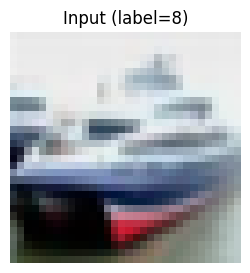

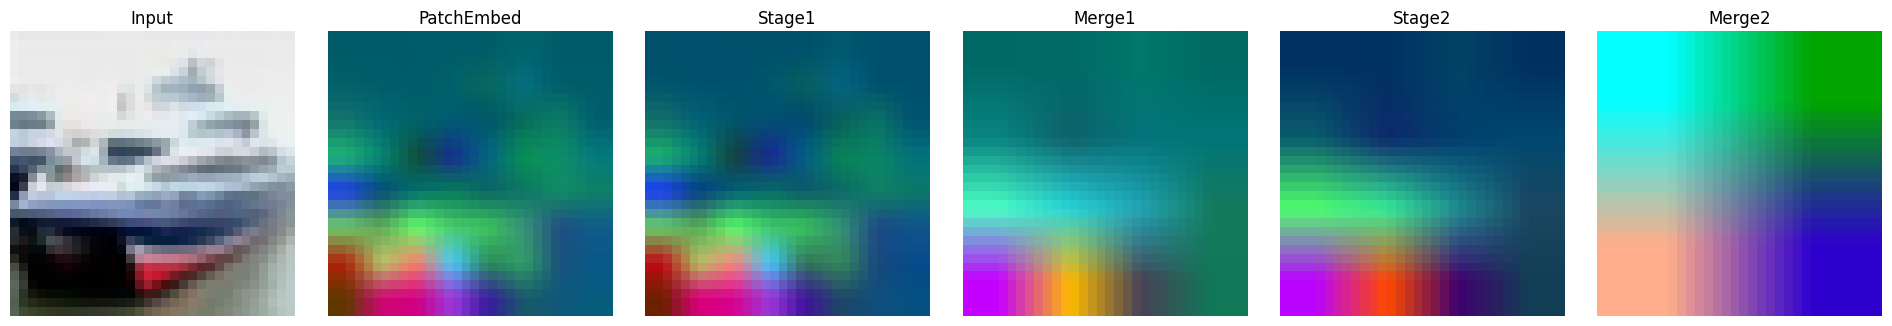

Stage1 token grid: 8x8, windows=4, N per window=16


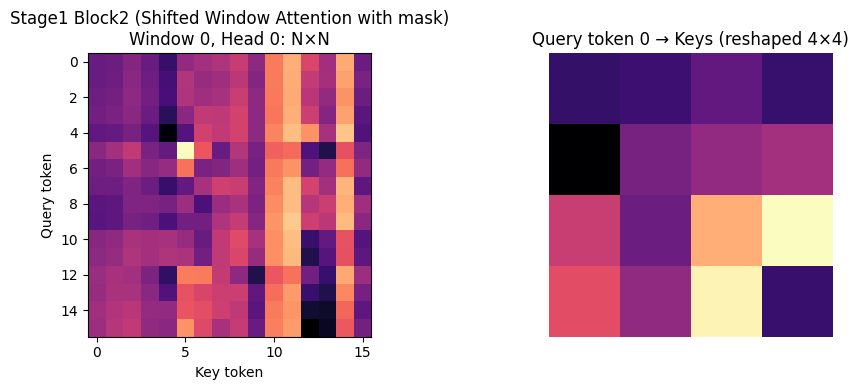

Stage2 token grid: 4x4, windows=1, N per window=16


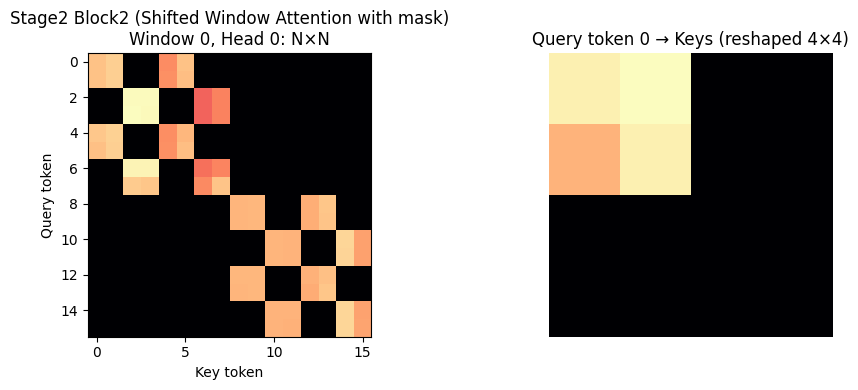

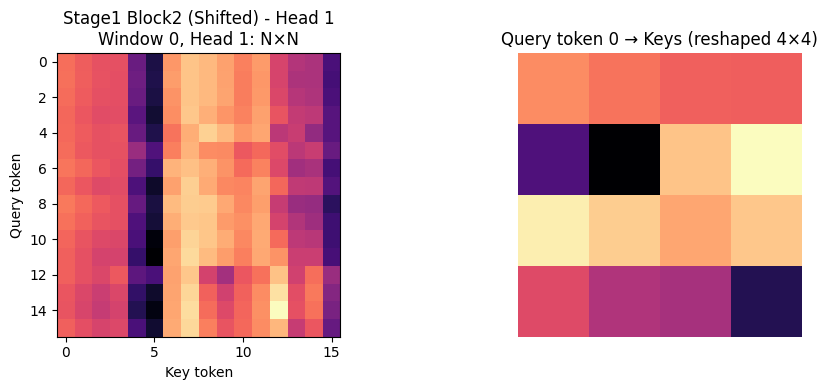

In [45]:
def main():
    device = get_device()
    print("Device:", device)

    # 1) Load ONE CIFAR-10 image
    tfm = transforms.Compose([transforms.ToTensor()])
    ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)
    img, label = ds[1]  # you can change index
    x = img.unsqueeze(0).to(device)  # (1,3,32,32)

    input_img = img.permute(1,2,0).cpu().numpy()

    plt.figure(figsize=(3,3))
    plt.imshow(input_img)
    plt.title(f"Input (label={label})")
    plt.axis("off")
    plt.show()

    # 2) Model + trace (with attention capture + proper mask)
    model = TinySwinCIFAR(patch_size=4, embed_dim=64, window_size=4, heads_stage1=2, heads_stage2=4).to(device)
    model.eval()

    with torch.no_grad():
        trace = model.forward_trace(x, capture_attn=True)

    # 3) Build PCA-RGB for each stage's token grid
    stage_names_for_rgb = ["PatchEmbed", "Stage1", "Merge1", "Stage2", "Merge2"]
    stage_rgbs = {}
    for name in stage_names_for_rgb:
        tok = trace[name]["tok"]       # (1,N,C)
        res = trace[name]["res"]       # (H,W)
        grid = tokens_to_grid(tok, res)[0]  # (H,W,C)
        rgb = pca_to_rgb(grid)
        stage_rgbs[name] = rgb

    # 4) Side-by-side: upsample all stages to 32×32 and compare
    show_side_by_side_upsampled(
        input_img_hw3=input_img,
        stage_rgbs_dict=stage_rgbs,
        target=32
    )

    # 5) Attention visualization per window/head
    # We'll visualize:
    # - Stage1 block2 (shifted) attention
    # - Stage2 block2 (shifted) attention
    #
    # You can change head/window/query_index to explore.

    # Stage1: token res = 8x8, window=4 => nW = 4 windows
    H1, W1 = trace["Stage1"]["res"]
    nW1 = list_num_windows(H1, W1, 4)
    print(f"Stage1 token grid: {H1}x{W1}, windows={nW1}, N per window={4*4}")

    attn_stage1_block2 = trace["Stage1"]["attn"][1]  # block2 attention (shifted)
    # Choose window 0, head 0, query token 0
    visualize_window_attention(
        attn=attn_stage1_block2,
        window_size=4,
        head=0,
        window_index=0,
        query_index=0,
        title="Stage1 Block2 (Shifted Window Attention with mask)"
    )

    # Stage2: token res = 4x4, window=4 => nW = 1 window
    H2, W2 = trace["Stage2"]["res"]
    nW2 = list_num_windows(H2, W2, 4)
    print(f"Stage2 token grid: {H2}x{W2}, windows={nW2}, N per window={4*4}")

    attn_stage2_block2 = trace["Stage2"]["attn"][1]  # shifted
    visualize_window_attention(
        attn=attn_stage2_block2,
        window_size=4,
        head=0,
        window_index=0,
        query_index=0,
        title="Stage2 Block2 (Shifted Window Attention with mask)"
    )

    # Optional: show multiple heads quickly
    # Example: Stage1 Block2 head 0 and head 1, same window/query
    if attn_stage1_block2.shape[1] > 1:
        visualize_window_attention(attn_stage1_block2, window_size=4, head=1, window_index=0, query_index=0,
                                   title="Stage1 Block2 (Shifted) - Head 1")

main()
